# Iteration 2: MobileNetV2 Transfer Learning

This notebook upgrades the baseline CNN by using MobileNetV2 pretrained on ImageNet and a custom classification head.

## What problem from the previous model are we solving, and how do we know it improved?

The previous baseline CNN is expected to overfit: it can memorize the training data but does not generalize well to validation images.

This iteration solves that by replacing the hand-built feature extractor with MobileNetV2, which already contains rich visual features learned from a very large dataset.

We will know it improved if validation accuracy increases, validation loss becomes more stable, and the confusion matrix shows fewer broad mistakes across many classes. This model is still expected to have some generalization limits because it does not yet use augmentation or fine-tuning, which are intentionally reserved for iteration 3.

In [22]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.2
GROUP_CHUNK_SIZE = 20
AUTOTUNE = tf.data.AUTOTUNE

tf.keras.utils.set_random_seed(SEED)
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.10.0


In [23]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('GPU detected and enabled:', gpus)
    except RuntimeError as error:
        print('GPU detected, but TensorFlow was already initialized:', error)
else:
    print('No GPU detected. TensorFlow will run on CPU.')

GPU detected and enabled: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [24]:
def find_dataset_root() -> Path:
    candidates = [
        Path.cwd() / 'Dataset',
        Path.cwd().parent / 'Dataset',
        Path.cwd().parent.parent / 'Dataset',
        Path('C:/Workkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkk/DLProject/Dataset')
    ]
    for candidate in candidates:
        if candidate.exists() and candidate.is_dir():
            class_dirs = [p for p in candidate.iterdir() if p.is_dir()]
            if class_dirs:
                return candidate.resolve()
    raise FileNotFoundError('Could not find the finalized Dataset folder.')

def natural_key(path: Path):
    parts = re.split(r'(\d+)', path.stem)
    return [int(part) if part.isdigit() else part.lower() for part in parts]

def extract_group_key(path: Path) -> str:
    match = re.search(r'(\d+)$', path.stem)
    chunk_id = int(match.group(1)) // GROUP_CHUNK_SIZE if match else 0
    prefix = re.sub(r'[_-]?\d+$', '', path.stem)
    return f'{path.parent.name}::{prefix}::chunk_{chunk_id:04d}'

def build_split_lists(dataset_root: Path, val_split: float = VAL_SPLIT):
    class_names = sorted([p.name for p in dataset_root.iterdir() if p.is_dir()])
    train_paths, train_labels = [], []
    val_paths, val_labels = [], []
    split_summary = []

    for class_index, class_name in enumerate(class_names):
        class_dir = dataset_root / class_name
        class_files = sorted([p for p in class_dir.iterdir() if p.is_file()], key=natural_key)
        grouped_files = {}
        for file_path in class_files:
            group_key = extract_group_key(file_path)
            grouped_files.setdefault(group_key, []).append(str(file_path))

        ordered_groups = sorted(grouped_files.items(), key=lambda item: item[0])
        val_group_count = max(1, int(round(len(ordered_groups) * val_split)))
        val_group_keys = {group_key for group_key, _ in ordered_groups[-val_group_count:]}

        class_train = 0
        class_val = 0
        for group_key, grouped_paths in ordered_groups:
            target_paths, target_labels = (val_paths, val_labels) if group_key in val_group_keys else (train_paths, train_labels)
            target_paths.extend(grouped_paths)
            target_labels.extend([class_index] * len(grouped_paths))
            if group_key in val_group_keys:
                class_val += len(grouped_paths)
            else:
                class_train += len(grouped_paths)

        split_summary.append({
            'class_name': class_name,
            'groups': len(ordered_groups),
            'train_images': class_train,
            'val_images': class_val
        })

    return class_names, train_paths, train_labels, val_paths, val_labels, split_summary

def decode_and_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label

def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

DATASET_ROOT = find_dataset_root()
CLASS_NAMES, train_paths, train_labels, val_paths, val_labels, split_summary = build_split_lists(DATASET_ROOT)
NUM_CLASSES = len(CLASS_NAMES)

print('Dataset root:', DATASET_ROOT)
print('Classes:', CLASS_NAMES)
print('Number of classes:', NUM_CLASSES)
print('Train images:', len(train_paths))
print('Validation images:', len(val_paths))
print('Sequence-aware split summary:')
for row in split_summary:
    print(row)

Dataset root: C:\Workkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkk\DLProject\Dataset
Classes: ['distracted', 'fatigue', 'focused', 'listening', 'raise_hand', 'sleeping', 'using_smartphone', 'writing_reading']
Number of classes: 8
Train images: 6873
Validation images: 1687
Sequence-aware split summary:
{'class_name': 'distracted', 'groups': 80, 'train_images': 1181, 'val_images': 301}
{'class_name': 'fatigue', 'groups': 52, 'train_images': 714, 'val_images': 172}
{'class_name': 'focused', 'groups': 64, 'train_images': 982, 'val_images': 250}
{'class_name': 'listening', 'groups': 82, 'train_images': 1313, 'val_images': 313}
{'class_name': 'raise_hand', 'groups': 54, 'train_images': 683, 'val_images': 177}
{'class_name': 'sleeping', 'groups': 41, 'train_images': 637, 'val_images': 152}
{'class_name': 'using_smartphone', 'groups': 25, 'train_images': 348, 'val_images': 88}
{'class_name': 'writing_reading', 'groups': 65, 'train_images': 1015, 'val_images': 234}


In [25]:
train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds = make_dataset(val_paths, val_labels, training=False)
class_names = CLASS_NAMES

In [26]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(
    64,
    activation='relu',
    kernel_regularizer=keras.regularizers.l2(5e-4)
)(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

transfer_model = keras.Model(inputs, outputs)
transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_8 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 tf.math.truediv_3 (TFOpLamb  (None, 224, 224, 3)      0         
 da)                                                             
                                                                 
 tf.math.subtract_3 (TFOpLam  (None, 224, 224, 3)      0         
 bda)                                                            
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_3   (None, 1280)             0         
 (GlobalAveragePooling2D)                                  

In [27]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)

history = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/12


215/215 [==============================] - 18s 51ms/step - loss: 1.8867 - accuracy: 0.4518 - val_loss: 1.3314 - val_accuracy: 0.6894 - lr: 5.0000e-05
Epoch 2/12
215/215 [==============================] - 16s 49ms/step - loss: 0.6446 - accuracy: 0.7981 - val_loss: 1.0621 - val_accuracy: 0.7919 - lr: 5.0000e-05
Epoch 3/12
215/215 [==============================] - 16s 49ms/step - loss: 0.3915 - accuracy: 0.8868 - val_loss: 0.9999 - val_accuracy: 0.8222 - lr: 5.0000e-05
Epoch 4/12
215/215 [==============================] - 16s 49ms/step - loss: 0.2732 - accuracy: 0.9329 - val_loss: 0.9989 - val_accuracy: 0.8364 - lr: 5.0000e-05
Epoch 5/12
215/215 [==============================] - ETA: 0s - loss: 0.2121 - accuracy: 0.9549
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
215/215 [==============================] - 17s 49ms/step - loss: 0.2121 - accuracy: 0.9549 - val_loss: 1.0306 - val_accuracy: 0.8435 - lr: 5.0000e-05
Epoch 6/12
214/215 [=========================

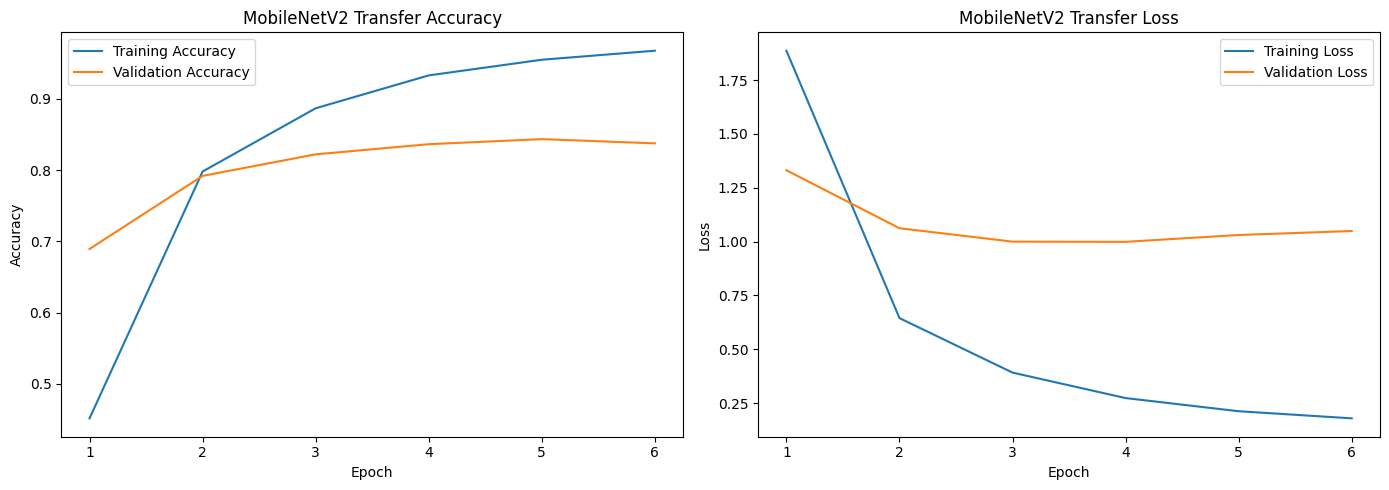

In [28]:
def plot_history(history, title_prefix='Model'):
    history_dict = history.history
    epochs = range(1, len(history_dict['loss']) + 1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_dict['accuracy'], label='Training Accuracy')
    plt.plot(epochs, history_dict['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title_prefix} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_dict['loss'], label='Training Loss')
    plt.plot(epochs, history_dict['val_loss'], label='Validation Loss')
    plt.title(f'{title_prefix} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()

plot_history(history, 'MobileNetV2 Transfer')

53/53 [==============================] - 3s 42ms/step
                  precision    recall  f1-score   support

      distracted       0.91      0.93      0.92       301
         fatigue       1.00      0.65      0.79       172
         focused       0.89      1.00      0.94       250
       listening       1.00      0.45      0.62       313
      raise_hand       0.48      0.93      0.63       177
        sleeping       0.86      1.00      0.93       152
using_smartphone       1.00      0.88      0.93        88
 writing_reading       0.94      1.00      0.97       234

        accuracy                           0.84      1687
       macro avg       0.89      0.85      0.84      1687
    weighted avg       0.89      0.84      0.83      1687



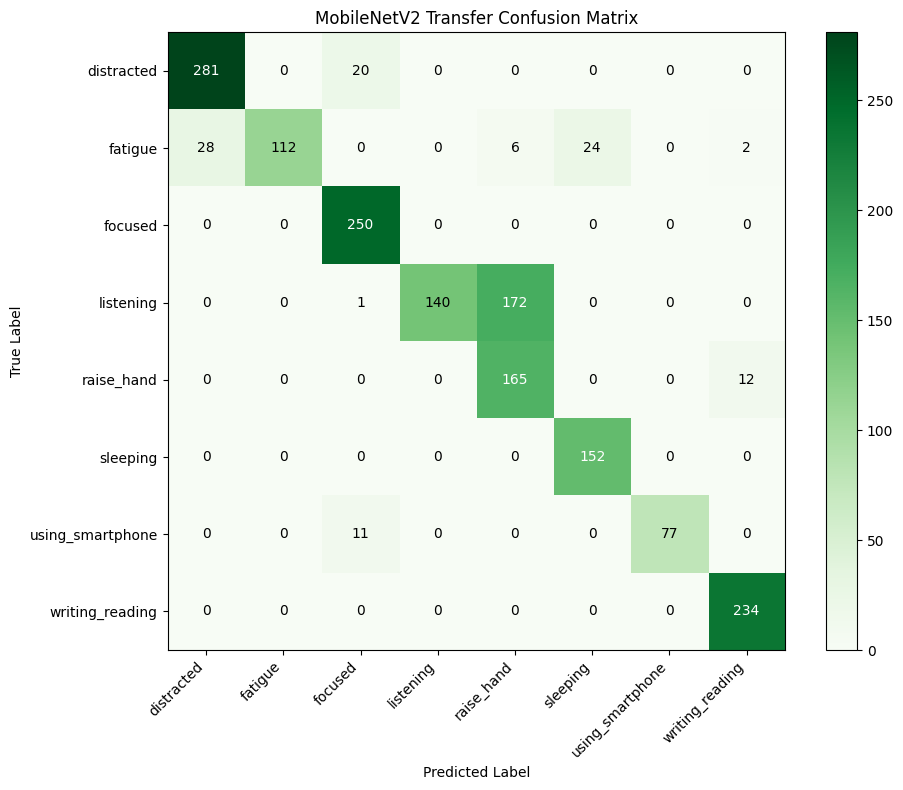

In [29]:
y_true = np.concatenate([labels.numpy() for _, labels in val_ds], axis=0)
y_prob = transfer_model.predict(val_ds)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Greens')
plt.title('MobileNetV2 Transfer Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha='right')
plt.yticks(tick_marks, class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

threshold = cm.max() / 2 if cm.max() > 0 else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='white' if cm[i, j] > threshold else 'black')
plt.tight_layout()

print(classification_report(y_true, y_pred, target_names=class_names))

## Evidence Summary

Expected improvement here: better validation accuracy and stronger overall classification than the leakage-corrected baseline CNN, but not perfect generalization.

If the confusion matrix still shows errors on classes such as `fatigue`, `sleeping`, or `using_smartphone`, that suggests a remaining generalization problem caused by limited variation in lighting, camera angle, and webcam quality. The next iteration will target that directly with augmentation and fine-tuning.